## Bước 4: EDA (Exploratory Data Analysis)
### 4.1 Đọc dữ liệu

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/depression_severity_no_leakage.csv')

print("Số dòng:", len(df))
print(df['label'].value_counts())

Số dòng: 3519
label
minimum     2555
moderate     393
mild         290
severe       281
Name: count, dtype: int64


### 4.2 Phân bố nhãn

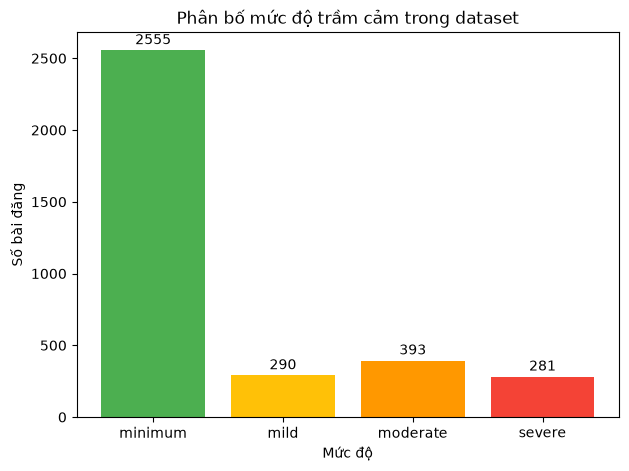

In [13]:
label_order = ['minimum', 'mild', 'moderate', 'severe']
counts = df['label'].value_counts().reindex(label_order)

plt.figure(figsize=(7, 5))
bars = plt.bar(counts.index, counts.values, color=['#4CAF50', '#FFC107', '#FF9800', '#F44336'])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 20, str(height),
              ha='center', va='bottom')

plt.title('Phân bố mức độ trầm cảm trong dataset')
plt.xlabel('Mức độ')
plt.ylabel('Số bài đăng')
plt.savefig('../outputs/figures/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Độ dài bài đăng theo từng nhãn

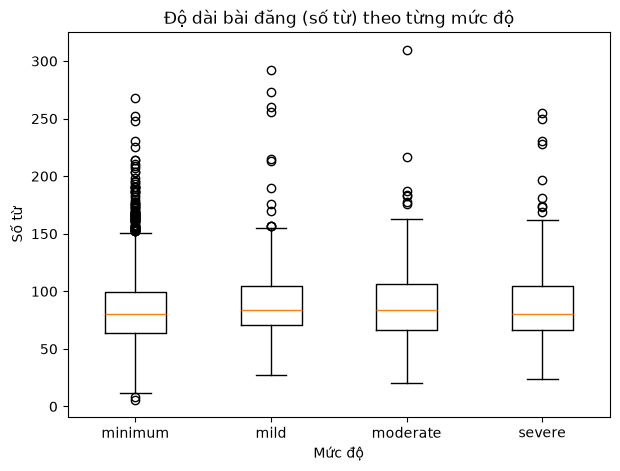

In [14]:
df['word_count'] = df['text'].str.split().str.len()

data_by_label = [df[df['label'] == lbl]['word_count'] for lbl in label_order]

plt.figure(figsize=(7, 5))
plt.boxplot(data_by_label, tick_labels=label_order)
plt.title('Độ dài bài đăng (số từ) theo từng mức độ')
plt.xlabel('Mức độ')
plt.ylabel('Số từ')
plt.savefig('../outputs/figures/wordcount_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 WordCloud theo từng nhãn

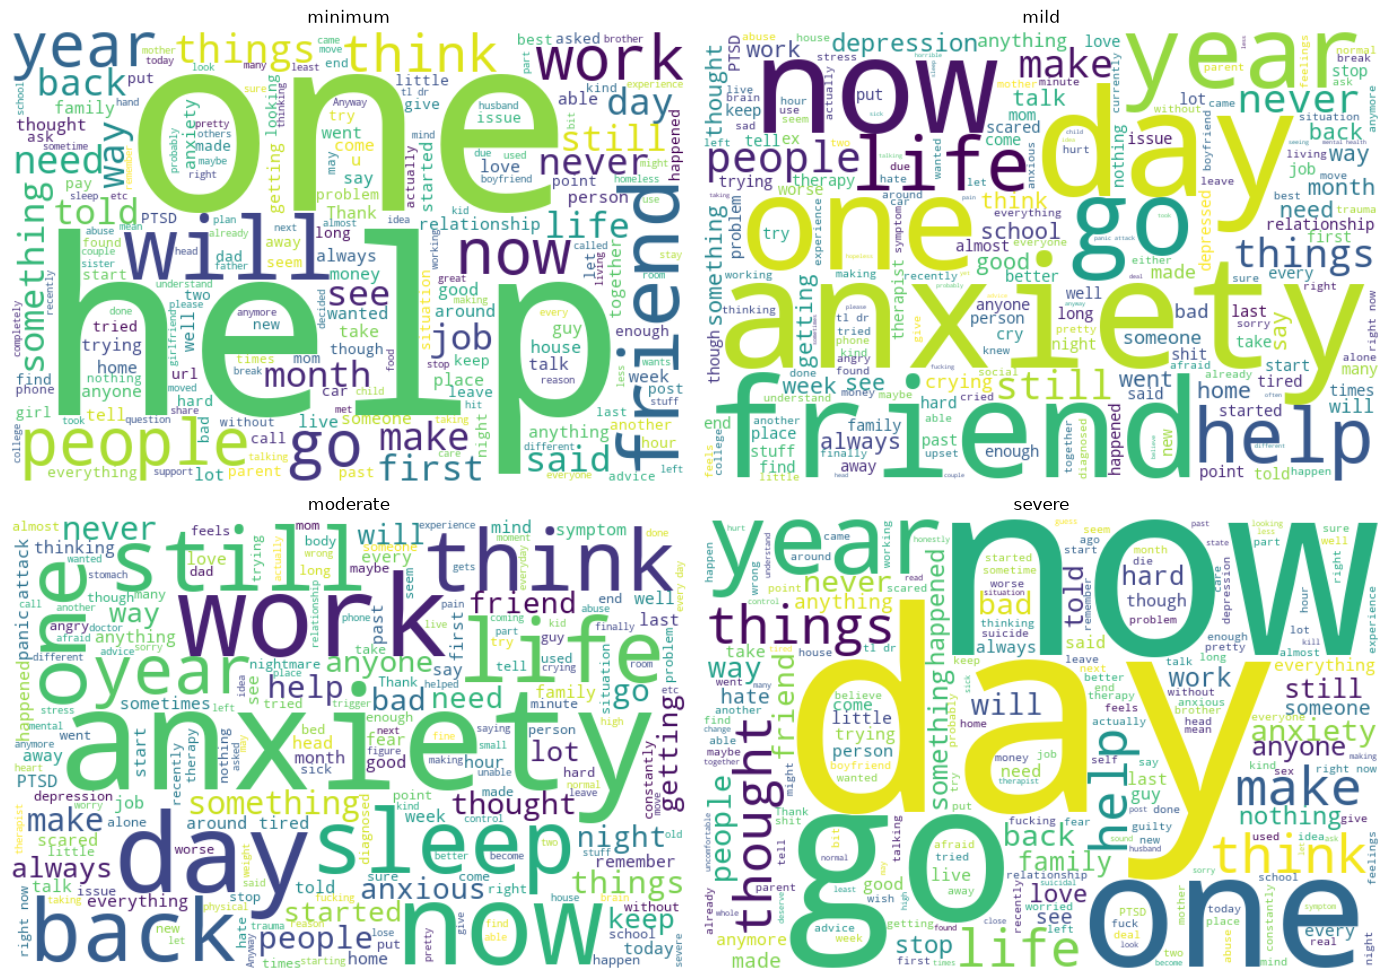

In [15]:
from wordcloud import WordCloud, STOPWORDS

custom_stopwords = set(STOPWORDS)
custom_stopwords.update(['feel', 'feeling', 'felt', 'know', 'thing', 'time',
                          'want', 'really', 'much', 'even', 'going', 'get', 'got'])
custom_stopwords.update(['don', 've', 'll', 're', 't', 's', 'm',
                          'aren', 'couldn', 'didn', 'doesn', 'hadn',
                          'hasn', 'haven', 'isn', 'mustn', 'shan',
                          'shouldn', 'wasn', 'weren', 'won', 'wouldn',
                          'like', 'just', 'im'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, lbl in zip(axes, label_order):
    text_combined = ' '.join(df[df['label'] == lbl]['text'])
    wc = WordCloud(width=600, height=400, background_color='white',
                    stopwords=custom_stopwords).generate(text_combined)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(lbl)
    ax.axis('off')

plt.tight_layout()
plt.savefig('../outputs/figures/wordcloud_by_label.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.5 Top N-gram theo từng nhãn

In [16]:
from sklearn.feature_extraction.text import CountVectorizer

custom_stopwords_list = list(custom_stopwords)
results = {}

for lbl in label_order:
    texts = df[df['label'] == lbl]['text']
    vectorizer = CountVectorizer(stop_words=custom_stopwords_list, ngram_range=(1, 2), max_features=15)
    counts = vectorizer.fit_transform(texts)
    freq = counts.sum(axis=0).A1
    top_words = sorted(zip(vectorizer.get_feature_names_out(), freq), key=lambda x: -x[1])
    results[lbl] = top_words

# In riêng từng nhãn để không bị dồn output quá dài 1 lần
for lbl in ['moderate', 'severe']:
    print(f"\n=== {lbl.upper()} ===")
    for word, count in results[lbl]:
        print(f"  {word}: {count}")

c:\Users\Thanh Hue\miniconda3\Lib\site-packages\sklearn\feature_extraction\text.py:412: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['let'] not in stop_words.
  warnings.warn(



=== MODERATE ===
  anxiety: 151
  now: 111
  work: 78
  sleep: 75
  day: 69
  life: 68
  still: 68
  back: 65
  never: 63
  something: 63
  think: 61
  one: 60
  go: 59
  people: 58
  things: 56

=== SEVERE ===
  now: 89
  go: 63
  things: 58
  one: 55
  life: 54
  think: 54
  help: 53
  anxiety: 51
  people: 50
  back: 49
  never: 48
  bad: 47
  day: 45
  will: 45
  way: 41


c:\Users\Thanh Hue\miniconda3\Lib\site-packages\sklearn\feature_extraction\text.py:412: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['let'] not in stop_words.
  warnings.warn(
c:\Users\Thanh Hue\miniconda3\Lib\site-packages\sklearn\feature_extraction\text.py:412: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['let'] not in stop_words.
  warnings.warn(
c:\Users\Thanh Hue\miniconda3\Lib\site-packages\sklearn\feature_extraction\text.py:412: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['let'] not in stop_words.
  warnings.warn(


In [17]:
print("=== SEVERE — Top 15 ===")
for word, count in results['severe'][:15]:
    print(f"  {word}: {count}")

=== SEVERE — Top 15 ===
  now: 89
  go: 63
  things: 58
  one: 55
  life: 54
  think: 54
  help: 53
  anxiety: 51
  people: 50
  back: 49
  never: 48
  bad: 47
  day: 45
  will: 45
  way: 41


### 4.6 Kiểm tra tần suất từ khóa cảnh báo theo nhãn

In [18]:
warning_words = ['suicide', 'suicidal', 'kill', 'die', 'death', 'worthless', 'hopeless', 'hate myself']

for word in warning_words:
    print(f"\nTừ '{word}':")
    for lbl in label_order:
        texts = df[df['label'] == lbl]['text'].str.lower()
        count = texts.str.contains(word, regex=False).sum()
        total = len(texts)
        print(f"  {lbl:10s}: {count:4d} / {total:4d} bài ({count/total*100:.1f}%)")


Từ 'suicide':
  minimum   :   17 / 2555 bài (0.7%)
  mild      :    2 /  290 bài (0.7%)
  moderate  :    2 /  393 bài (0.5%)
  severe    :   18 /  281 bài (6.4%)

Từ 'suicidal':
  minimum   :    5 / 2555 bài (0.2%)
  mild      :    0 /  290 bài (0.0%)
  moderate  :    3 /  393 bài (0.8%)
  severe    :    9 /  281 bài (3.2%)

Từ 'kill':
  minimum   :   52 / 2555 bài (2.0%)
  mild      :   10 /  290 bài (3.4%)
  moderate  :   14 /  393 bài (3.6%)
  severe    :   24 /  281 bài (8.5%)

Từ 'die':
  minimum   :   86 / 2555 bài (3.4%)
  mild      :   11 /  290 bài (3.8%)
  moderate  :   14 /  393 bài (3.6%)
  severe    :   17 /  281 bài (6.0%)

Từ 'death':
  minimum   :   18 / 2555 bài (0.7%)
  mild      :    4 /  290 bài (1.4%)
  moderate  :    4 /  393 bài (1.0%)
  severe    :    6 /  281 bài (2.1%)

Từ 'worthless':
  minimum   :    3 / 2555 bài (0.1%)
  mild      :    7 /  290 bài (2.4%)
  moderate  :    1 /  393 bài (0.3%)
  severe    :    6 /  281 bài (2.1%)

Từ 'hopeless':
  minimum   

## Bổ sung: dữ liệu thiếu, outlier và fairness

Phần này kiểm tra giá trị thiếu/blank, nhãn không hợp lệ, bản ghi trùng còn sót và các ngoại lệ về độ dài bài đăng. Outlier chỉ được gắn cờ để xem xét, không tự động loại bỏ. Dataset không có thuộc tính bảo vệ nên không thể tính fairness theo nhóm nhân khẩu học; báo cáo chỉ nêu giới hạn và có thể phân tích hiệu năng theo độ dài văn bản sau khi có prediction file.

In [ ]:
import subprocess
import sys
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
subprocess.run(
    [sys.executable, 'src/data_quality_fairness.py'],
    cwd=PROJECT_ROOT,
    check=True,
)


In [ ]:
import pandas as pd
from pathlib import Path

report_dir = Path('../outputs/reports')
display(pd.read_csv(report_dir / 'missing_data_report.csv'))
display(pd.read_csv(report_dir / 'text_length_outlier_summary.csv'))
print((report_dir / 'data_quality_fairness_report.md').read_text(encoding='utf-8'))
